# MLP Baseline — Регрессия популярности банкоматов

## Описание задачи

Задача: **регрессия** — предсказание показателя популярностикаждого банкомата.  
Метрика оптимизации: **RMSE** (чем меньше — тем лучше).  

Признаки делятся на четыре группы:
- **Бинарные (17)** — наличие сервисов (cash_in, cash_out, contactless и др.)
- **Расстояния (17)** — до ближайших объектов инфраструктуры (метры)
- **Счётчики (25)** — количество объектов в радиусе 300 м
- **Экономические (4)** — средняя зарплата, ВВП на душу, плотность населения
- **Категориальные (4)** — федеральный округ и тп

Сплит: **Train 70% / Val 15% / Test 15%**.

## Архитектура модели

Полносвязная сеть (MLP) со следующей схемой:

```
Input(67) → BatchNorm → [Linear → BatchNorm → ReLU → Dropout(0.3)] × 3 → Linear → Output(1)
```

| Слой | Размерность |
|---|---|
| Entry | 67 |
| Hidden 1 | 256 |
| Hidden 2 | 128 |
| Hidden 3 | 64 |
| Exit | 1 |

- BatchNorm на входе стабилизирует масштаб признаков.  
- Dropout (p=0.3) в каждом блоке предотвращает переобучение.  
- Оптимизатор: **Adam** (lr=1e-3, weight_decay=1e-4).  
- Scheduler: **ReduceLROnPlateau** (×0.5 при отсутствии улучшений 10 эпох).  
- Early stopping: терпение 20 эпох по val RMSE.

## 1. Импорты

In [9]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from pathlib import Path



DATA_PATH  = Path("../../data/train_data_v2.csv")
MODELS_DIR = Path("../../models")
MODELS_DIR.mkdir(exist_ok=True)

pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

N_TRIALS = 50

RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device  : {DEVICE}", f"({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else "")

Device  : cuda (NVIDIA GeForce RTX 5080)


## 2. Загрузка данных и предобработка

In [10]:
# Читаем датасет
df = pd.read_csv(DATA_PATH)
print(f'Датасет: {df.shape[0]} строк × {df.shape[1]} колонок')

Датасет: 6200 строк × 134 колонок


In [11]:
# Бинарные признаки
BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center',
    'has_subway_nearby',
]

# Расстояния до ближайших объектов инфраструктуры (в метрах)
DISTANCE_FEATURES = [
    'nearest_malls_dist_m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m', 'nearest_public_transport_dist_m',
    'nearest_parking_dist_m', 'nearest_education_dist_m', 'nearest_subway_dist_m',
    'nearest_post_offices_dist_m', 'nearest_offices_dist_m',
    'nearest_shops_food_small_dist_m', 'nearest_fitness_sport_dist_m',
    'nearest_hotels_hostels_dist_m', 'land_use_dist_m', 'city_center_dist_m',
    'nearest_residential_landuse_dist_m',
]

# Количество объектов в радиусе 300 м от банкомата
COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m', 'count_pharmacies_hospitals_300m',
    'count_banks_atms_300m', 'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m', 'count_education_300m',
    'count_post_offices_300m', 'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m', 'count_hypermarkets_300m',
    'count_markets_300m', 'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m',
    'count_footway_100m_100m',
]

# Макроэкономические показатели региона
ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub', 'grp_per_capita_2023_rub',
    'avg_income_q3_2025_rub', 'population_density_per_km2',
]

# Категориальные признаки
CATEGORICAL_FEATURES = ['federal_district', 'city_size_category', 'land_use_type', 'atm_group']

# Итоговый список признаков
ALL_FEATURES = (
    BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES +
    ECONOMIC_FEATURES + CATEGORICAL_FEATURES
)
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
CONT_COLS = [f for f in ALL_FEATURES if f not in CATEGORICAL_FEATURES]

print(f'Всего признаков: {len(ALL_FEATURES)}')

Всего признаков: 67


In [12]:
X = df[ALL_FEATURES].copy()
y = df['target'].values.reshape(-1, 1).astype(np.float32)

# Булевые столбцы приводим к int
for col in BINARY_FEATURES:
    if col in X.columns and X[col].dtype == bool:
        X[col] = X[col].astype(int)

strat_col = df['city_size_category'].fillna('unknown')

# отделяем test (15%), затем из остатка val (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=strat_col,
)
strat_trainval = strat_col.loc[X_trainval.index]
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=strat_trainval,
)

# Пайплайн для непрерывных признаков
imp_cont = SimpleImputer(strategy='median')
scaler   = StandardScaler()

def process_cont(X_df, fit=False):
    vals = X_df[CONT_COLS].copy().astype(float)
    # сжимаем длинные хвосты у расстояний
    for c in DISTANCE_FEATURES:
        if c in vals.columns:
            vals[c] = np.log1p(vals[c].clip(lower=0))
    if fit:
        imp_cont.fit(vals)
        scaler.fit(imp_cont.transform(vals))
    return scaler.transform(imp_cont.transform(vals)).astype(np.float32)

# Пайплайн для категориальных признаков
enc_cat = OrdinalEncoder(
    handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.float32,
)

def process_cat(X_df, fit=False):
    vals = X_df[CATEGORICAL_FEATURES].fillna('unknown').astype(str)
    if fit:
        enc_cat.fit(vals)
    encoded = enc_cat.transform(vals).astype(np.float32)
    for j in range(encoded.shape[1]):
        n_known = len(enc_cat.categories_[j])
        encoded[:, j] = np.where(encoded[:, j] < 0, float(n_known), encoded[:, j])
    return encoded

# Обучаем трансформеры
process_cont(X_train, fit=True)
process_cat(X_train, fit=True)

# конкатенируем непрерывные + категориальные признаки
X_train_np = np.hstack([process_cont(X_train), process_cat(X_train)])
X_val_np = np.hstack([process_cont(X_val), process_cat(X_val)])
X_test_np = np.hstack([process_cont(X_test), process_cat(X_test)])
X_trainval_np = np.hstack([process_cont(X_trainval), process_cat(X_trainval)])
y_trainval_np = np.vstack([y_train, y_val])

INPUT_DIM = X_train_np.shape[1]
print(f'Train: {X_train_np.shape}, Val: {X_val_np.shape}, Test: {X_test_np.shape}')

Train: (4339, 67), Val: (931, 67), Test: (930, 67)


## 3. Архитектура MLP

```
Input → BatchNorm → [Linear → BatchNorm → ReLU → Dropout] × N → Linear → Output
```

In [13]:
class MLP(nn.Module):
    """
    Полносвязная сеть с BatchNorm и Dropout
    """
    def __init__(self, input_dim: int, hidden_dims: list[int], output_dim: int = 1,dropout: float = 0.3):

        super().__init__()

        # Нормализация всхе признаков всех признаков
        layers = [nn.BatchNorm1d(input_dim)]

        # Построение скрытых блоков
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h), # линейное преобразование
                nn.BatchNorm1d(h), # нормализация
                nn.ReLU(), # добавляем нелинейность
                nn.Dropout(dropout), # регуляризация
            ]
            in_dim = h

        # Выходной слой
        layers.append(nn.Linear(in_dim, output_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# Конфигурация модели
HIDDEN_DIMS = [256, 128, 64] # три скрытых слоя: 256 → 128 → 64
DROPOUT = 0.3 # 30% нейронов случайно отключается при обучении

model = MLP(INPUT_DIM, HIDDEN_DIMS, output_dim=1, dropout=DROPOUT).to(DEVICE)

## 4. DataLoader

In [14]:
BATCH_SIZE = 512

def make_loader(X_np, y_np, shuffle=True):
    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader    = make_loader(X_train_np, y_train)
val_loader      = make_loader(X_val_np, y_val, shuffle=False)
test_loader     = make_loader(X_test_np, y_test, shuffle=False)
trainval_loader = make_loader(X_trainval_np, y_trainval_np)

## 5. Подбор гиперпараметров - Optuna

In [15]:
def objective(trial):
    # Перебираем разное количество скрытых слоёв
    n_layers = trial.suggest_int('n_layers', 1, 4)
    hidden_dims = [
        trial.suggest_categorical(f'hidden_{i}', [64, 128, 256, 512])
        for i in range(n_layers)
    ]

    # Подбираем dropout, lr и weight_decay
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)

    model_trial = MLP(INPUT_DIM, hidden_dims, output_dim=1, dropout=dropout).to(DEVICE)
    opt_trial   = torch.optim.Adam(model_trial.parameters(), lr=lr, weight_decay=weight_decay)
    crit_trial  = nn.MSELoss()

    best_val = float('inf')
    no_imp   = 0

    for epoch in range(100):
        model_trial.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = model_trial(X_batch)
            loss  = crit_trial(preds, y_batch)
            opt_trial.zero_grad()
            loss.backward()
            opt_trial.step()

        # Считаем val RMSE
        model_trial.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                preds     = model_trial(X_batch.to(DEVICE))
                val_loss += crit_trial(preds, y_batch.to(DEVICE)).item() * len(X_batch)
        val_rmse = np.sqrt(val_loss / len(val_loader.dataset))

        trial.report(val_rmse, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Early stopping внутри триала
        if val_rmse < best_val:
            best_val = val_rmse
            no_imp   = 0
        else:
            no_imp += 1
            if no_imp >= 10:
                break

    return best_val

# Запускаем подбор гиперпараметров
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=10)
study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f'Лучший val RMSE по Optuna: {study.best_value:.4f}')
print(f'Лучшие параметры: {best_params}')

best_hidden_dims = [
    best_params[f'hidden_{i}'] for i in range(best_params['n_layers'])
]

Best trial: 49. Best value: 0.0478381: 100%|██████████| 50/50 [00:52<00:00,  1.05s/it]

Лучший val RMSE по Optuna: 0.0478
Лучшие параметры: {'n_layers': 1, 'hidden_0': 128, 'dropout': 0.20934817156315547, 'lr': 0.004085571660264247, 'weight_decay': 0.00038707764480295186}


## 6. Обучение Baseline

In [16]:
HIDDEN_DIMS  = [256, 128, 64]
DROPOUT      = 0.3
LR           = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 200
PATIENCE     = 20

model = MLP(INPUT_DIM, HIDDEN_DIMS, output_dim=1, dropout=DROPOUT).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6,
)

def run_epoch(loader, mdl, opt, train=True):
    mdl.train() if train else mdl.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = mdl(X_batch)
            loss  = criterion(preds, y_batch)
            if train:
                opt.zero_grad()
                loss.backward()
                opt.step()
            total_loss += loss.item() * len(X_batch)
    return np.sqrt(total_loss / len(loader.dataset))

history_base       = {'train_rmse': [], 'val_rmse': []}
best_val_rmse_base = float('inf')
best_state_base    = None
no_improve         = 0

t0 = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    tr_rmse  = run_epoch(train_loader, model, optimizer, train=True)
    val_rmse = run_epoch(val_loader, model, optimizer, train=False)
    scheduler.step(val_rmse)

    history_base['train_rmse'].append(tr_rmse)
    history_base['val_rmse'].append(val_rmse)

    if val_rmse < best_val_rmse_base:
        best_val_rmse_base = val_rmse
        best_state_base = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch_base = epoch
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping: эпоха {epoch}')
            break

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Эпоха {epoch:3d}, train RMSE={tr_rmse:.4f}, val RMSE={val_rmse:.4f}, lr={lr_now:.2e}')

fit_time_base = time.perf_counter() - t0
model.load_state_dict(best_state_base)
print(f'\nВремя обучения (baseline): {fit_time_base:.1f} с')
print(f'Лучший val RMSE (baseline): {best_val_rmse_base:.4f}')

Эпоха   1, train RMSE=0.3894, val RMSE=0.1194, lr=1.00e-03
Эпоха   2, train RMSE=0.3086, val RMSE=0.1125, lr=1.00e-03
Эпоха   3, train RMSE=0.2630, val RMSE=0.1099, lr=1.00e-03
Эпоха   4, train RMSE=0.2328, val RMSE=0.0978, lr=1.00e-03
Эпоха   5, train RMSE=0.2167, val RMSE=0.0936, lr=1.00e-03
Эпоха   6, train RMSE=0.1861, val RMSE=0.0850, lr=1.00e-03
Эпоха   7, train RMSE=0.1685, val RMSE=0.0806, lr=1.00e-03
Эпоха   8, train RMSE=0.1532, val RMSE=0.0762, lr=1.00e-03
Эпоха   9, train RMSE=0.1410, val RMSE=0.0724, lr=1.00e-03
Эпоха  10, train RMSE=0.1274, val RMSE=0.0703, lr=1.00e-03
Эпоха  11, train RMSE=0.1191, val RMSE=0.0696, lr=1.00e-03
Эпоха  12, train RMSE=0.1124, val RMSE=0.0678, lr=1.00e-03
Эпоха  13, train RMSE=0.1049, val RMSE=0.0668, lr=1.00e-03
Эпоха  14, train RMSE=0.1018, val RMSE=0.0663, lr=1.00e-03
Эпоха  15, train RMSE=0.0968, val RMSE=0.0656, lr=1.00e-03
Эпоха  16, train RMSE=0.0936, val RMSE=0.0654, lr=1.00e-03
Эпоха  17, train RMSE=0.0910, val RMSE=0.0650, lr=1.00e-

## 7. Обучение Optuna-модели

In [17]:
model_opt = MLP(
    INPUT_DIM,
    best_hidden_dims,
    output_dim=1,
    dropout=best_params['dropout']
).to(DEVICE)

optimizer_opt = torch.optim.Adam(
    model_opt.parameters(),
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay']
)
scheduler_opt = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_opt, mode='min', factor=0.5, patience=10, min_lr=1e-6,
)

history_opt        = {'train_rmse': [], 'val_rmse': []}
best_val_rmse_opt  = float('inf')
best_state_opt     = None
no_improve_opt     = 0

t0 = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    tr_rmse  = run_epoch(train_loader, model_opt, optimizer_opt, train=True)
    val_rmse = run_epoch(val_loader,   model_opt, optimizer_opt, train=False)
    scheduler_opt.step(val_rmse)

    history_opt['train_rmse'].append(tr_rmse)
    history_opt['val_rmse'].append(val_rmse)

    if val_rmse < best_val_rmse_opt:
        best_val_rmse_opt = val_rmse
        best_state_opt = {k: v.cpu().clone() for k, v in model_opt.state_dict().items()}
        best_epoch_opt = epoch
        no_improve_opt = 0
    else:
        no_improve_opt += 1
        if no_improve_opt >= PATIENCE:
            print(f'Early stopping: эпоха {epoch}')
            break

    lr_now = optimizer_opt.param_groups[0]['lr']
    print(f'Эпоха {epoch:3d}, train RMSE={tr_rmse:.4f}, val RMSE={val_rmse:.4f}, lr={lr_now:.2e}')

fit_time_opt = time.perf_counter() - t0
model_opt.load_state_dict(best_state_opt)
print(f'\nВремя обучения (Optuna): {fit_time_opt:.1f} с')
print(f'Лучший val RMSE (Optuna): {best_val_rmse_opt:.4f}')

Эпоха   1, train RMSE=0.3214, val RMSE=0.1490, lr=4.09e-03
Эпоха   2, train RMSE=0.2065, val RMSE=0.1003, lr=4.09e-03
Эпоха   3, train RMSE=0.1469, val RMSE=0.0823, lr=4.09e-03
Эпоха   4, train RMSE=0.1145, val RMSE=0.0721, lr=4.09e-03
Эпоха   5, train RMSE=0.0918, val RMSE=0.0681, lr=4.09e-03
Эпоха   6, train RMSE=0.0809, val RMSE=0.0654, lr=4.09e-03
Эпоха   7, train RMSE=0.0719, val RMSE=0.0617, lr=4.09e-03
Эпоха   8, train RMSE=0.0663, val RMSE=0.0597, lr=4.09e-03
Эпоха   9, train RMSE=0.0623, val RMSE=0.0579, lr=4.09e-03
Эпоха  10, train RMSE=0.0611, val RMSE=0.0568, lr=4.09e-03
Эпоха  11, train RMSE=0.0590, val RMSE=0.0561, lr=4.09e-03
Эпоха  12, train RMSE=0.0578, val RMSE=0.0556, lr=4.09e-03
Эпоха  13, train RMSE=0.0553, val RMSE=0.0550, lr=4.09e-03
Эпоха  14, train RMSE=0.0552, val RMSE=0.0555, lr=4.09e-03
Эпоха  15, train RMSE=0.0544, val RMSE=0.0534, lr=4.09e-03
Эпоха  16, train RMSE=0.0530, val RMSE=0.0535, lr=4.09e-03
Эпоха  17, train RMSE=0.0528, val RMSE=0.0530, lr=4.09e-

## 8. Кривые обучения - Baseline vs Optuna

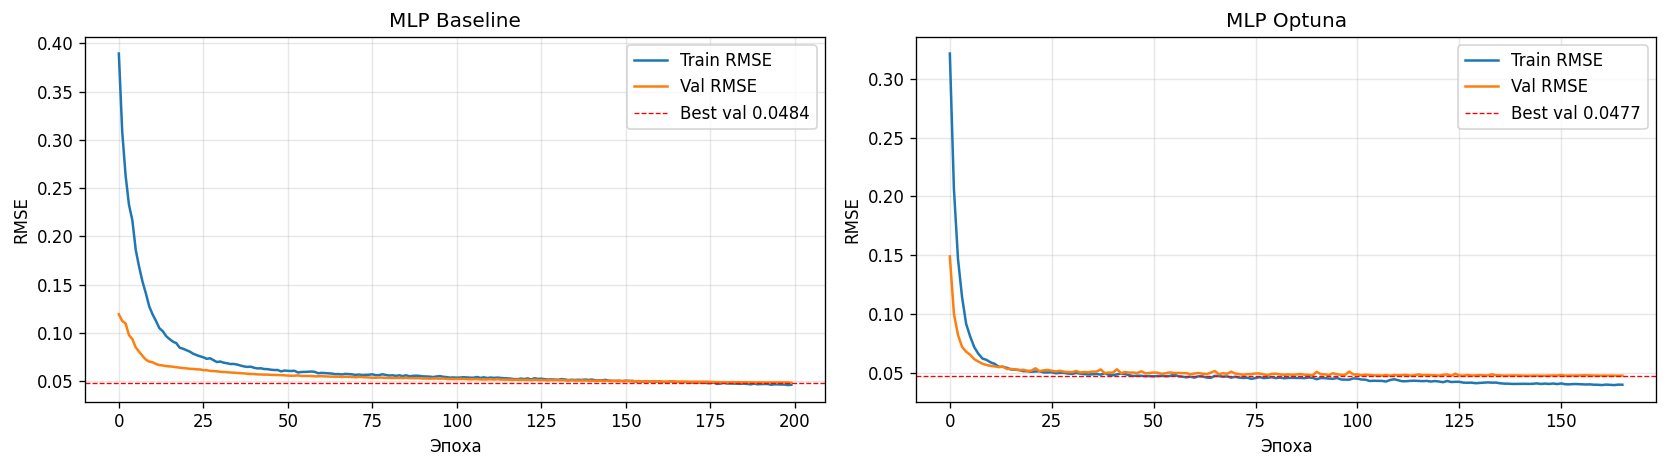

In [18]:
# Сравниваем динамику обучения двух моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, history, label, best in [
    (axes[0], history_base, 'Baseline', best_val_rmse_base),
    (axes[1], history_opt,  'Optuna',   best_val_rmse_opt),
]:
    ax.plot(history['train_rmse'], label='Train RMSE')
    ax.plot(history['val_rmse'],   label='Val RMSE')
    ax.axhline(best, color='red', ls='--', lw=0.8, label=f'Best val {best:.4f}')
    ax.set_title(f'MLP {label}')
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('RMSE')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Метрики на тестовой выборке

In [19]:
def predict_np(mdl, loader):
    """
    Возвращает предсказания в numpy
    """
    mdl.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            preds.append(mdl(X_batch.to(DEVICE)).cpu().numpy())
    return np.concatenate(preds).flatten()

def metrics(y_true, y_pred):
    """
    Возвращает словарь с RMSE, MAE, R²
    """
    return {
        'RMSE': round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        'MAE': round(float(mean_absolute_error(y_true, y_pred)), 4),
        'R²': round(float(r2_score(y_true, y_pred)), 4),
    }

# Предсказания моделей на test
y_pred_base = predict_np(model, test_loader)
y_pred_opt  = predict_np(model_opt, test_loader)
y_test_flat = y_test.flatten()

# Собираем итоговую таблицу результатов
res = pd.DataFrame([
    {'Модель': 'MLP Baseline', **metrics(y_test_flat, y_pred_base)},
    {'Модель': 'MLP + Optuna', **metrics(y_test_flat, y_pred_opt)},
]).set_index('Модель')

display(
    res.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}', 'Fit time, s': '{:.1f}'})
    .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s], subset=['RMSE', 'MAE'])
    .apply(lambda s: ['font-weight: bold' if v == s.max() else '' for v in s], subset=['R²'])
)

,RMSE,MAE,R²
Модель,,,
MLP Baseline,0.0513,0.0406,0.6469
MLP + Optuna,0.0495,0.0396,0.6710


## 10. Сохранение лучшей модели

In [20]:
# Финальное переобучение на train+val (best_epoch эпох, без early stopping)
print(f"Финальное обучение baseline: {best_epoch_base} эпох на train+val...")
model_base_final = MLP(INPUT_DIM, HIDDEN_DIMS, output_dim=1, dropout=DROPOUT).to(DEVICE)
opt_base_final   = torch.optim.Adam(model_base_final.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
for _ in range(best_epoch_base):
    run_epoch(trainval_loader, model_base_final, opt_base_final, train=True)

print(f"Финальное обучение Optuna:   {best_epoch_opt} эпох на train+val...")
model_opt_final = MLP(INPUT_DIM, best_hidden_dims, output_dim=1, dropout=best_params["dropout"]).to(DEVICE)
opt_opt_final   = torch.optim.Adam(model_opt_final.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])
for _ in range(best_epoch_opt):
    run_epoch(trainval_loader, model_opt_final, opt_opt_final, train=True)

for name, mdl, hd, dp, val_rmse in [
    ("mlp_baseline.pt", model_base_final, HIDDEN_DIMS,       DROPOUT,                   best_val_rmse_base),
    ("mlp_optuna.pt",   model_opt_final,  best_hidden_dims,  best_params["dropout"],    best_val_rmse_opt),
]:
    torch.save({
        "model_state_dict": mdl.state_dict(),
        "hidden_dims":      hd,
        "dropout":          dp,
        "input_dim":        INPUT_DIM,
        "val_rmse":         val_rmse,
    }, MODELS_DIR / name)
    print(f"Сохранено: {MODELS_DIR / name}")

Финальное обучение baseline: 200 эпох на train+val...
Финальное обучение Optuna:   146 эпох на train+val...
Сохранено: ..\..\models\mlp_baseline.pt
Сохранено: ..\..\models\mlp_optuna.pt


## 11. Выводы

### Результаты обучения

**Baseline** обучался все 200 эпох (early stopping не сработал), лучший val RMSE = **0.0484**.  
**Optuna** остановился на эпохе 166 (early stopping сработал), лучший val RMSE = **0.0477**.

### Baseline vs Optuna на тестовой выборке

| Модель | RMSE | MAE | R² |
|--------|------|-----|----|
| MLP Baseline | 0.0513 | 0.0406 | 0.6469 |
| **MLP + Optuna** | **0.0495** | **0.0396** | **0.6710** |

Optuna улучшила все три метрики:
- RMSE снизился с 0.0513 до 0.0495
- R² вырос с 0.647 до 0.671